簡単な３つの文章で動かしてみた後、datasetからのデータで実験してみる

In [ ]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW

model_name = "cl-tohoku/bert-base-japanese-v3"
num_classes = 2 

# トークナイザー（文字をIDのテンソルに変換するツール）
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 分類用BERTモデル（12層のあとに[CLS]を抽出して全結合層に通す処理が最初から組まれている）
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=num_classes
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

texts = [
    "この映画は本当に素晴らしかった。感動して涙が出た。",
    "全然面白くない。時間を無駄にした気分だ。",
    "ストーリーは普通だが、映像はとても綺麗だった。"
]

labels = torch.tensor([1, 0, 1]) # 1:ポジティブ, 0:ネガティブ

encoded_data = tokenizer(
    texts,
    padding=True,                      # バッチ内の最大長に合わせて[PAD]で埋める
    truncation=True,                   # 512トークンを超えたら切り捨てる
    max_length=512,
    return_tensors="pt"                # PyTorchのテンソル(pt)として返す
)


input_ids = encoded_data["input_ids"].to(device)
attention_mask = encoded_data["attention_mask"].to(device)
token_type_ids = encoded_data["token_type_ids"].to(device)
labels = labels.to(device)


optimizer = AdamW(model.parameters(), lr=2e-5) # BERTの微調整は2e-5などの非常に小さな学習率が鉄則



I0000 00:00:1781684550.786097   43051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781684550.834560   43051 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781684551.668514   43051 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-toh

In [5]:
encoded_data['attention_mask']

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]])

In [2]:
model.train()
epochs = 3

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
        labels=labels # ここに正解ラベルを渡すと、モデル内部で自動的にLossを計算してくれる！
    )
    
    loss = outputs.loss
    logits = outputs.logits # (Batch, 2) の確率の元データ
    
    # バックプロパゲーション（12層すべての重みを微調整）
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")


model.eval()
test_text = "期待して見に行ったけど、想像以上に最高だった！"

# 推論時も入力の形を揃える
inputs = tokenizer(test_text, return_tensors="pt").to(device)

with torch.no_grad():
    test_outputs = model(**inputs) # **inputs で辞書を展開して渡す
    predictions = torch.argmax(test_outputs.logits, dim=-1)

print(f"\n入力文: {test_text}")
print(f"予測ラベル: {'ポジティブ' if predictions.item() == 1 else 'ネガティブ'}")

Epoch 1 | Loss: 0.7011
Epoch 2 | Loss: 0.5297
Epoch 3 | Loss: 0.3836

入力文: 期待して見に行ったけど、想像以上に最高だった！
予測ラベル: ポジティブ


ここから大規模データに対して、適応

In [5]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset

In [6]:
model_name = "cl-tohoku/bert-base-japanese-v3"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [7]:
dataset = load_dataset("shunk031/livedoor-news-corpus")

README.md: 0.00B [00:00, ?B/s]

livedoor-news-corpus.py: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

datasetは以下の内容

In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 5894
    })
    validation: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 737
    })
    test: Dataset({
        features: ['url', 'date', 'title', 'content', 'category'],
        num_rows: 736
    })
})

結構ながい

In [14]:
dataset['train']['content'][0]

'今年4月より世界各国で公開され、歴代3位の興行収入14億ドル（6月27日現在）を突破している『アベンジャーズ』。日本での公開は8月14日からとなるが、2位『タイタニック』（1997年公開）の21億、その上の1位『アバター』（2009年公開）の27億という壁はまだ高く、そして険しい。  『タイタニック』でレオナルド・ディカプリオ演じる主人公ジャックが背後から支え、ケイト・ウィンスレット演じるヒロインのローズが両手を広げる船首での有名なシーンは、誰もが一度は真似た経験があるだろう。二人は本作でブレイクを果たし、ケイト・ウィンスレットは2008年公開の『愛を読むひと』でアカデミー主演女優賞を受賞。その一方で、今年も『J・エドガー』でアカデミー主演男優賞のノミネートから漏れてしまったレオ様だが、『タイタニック』の大ヒットでアイドル的なスーパー・スターの座に上り詰めてしまったことが裏目に出たとの声もある。  そしてこの夏、『アバター』で主人公とヒロインを演じた二人の主演作が続けて公開される。  まずは、主人公ジェイク役を演じたサム・ワーシントン主演の最新作『崖っぷちの男』が、7月7日に公開。今や名実ともにハリウッドのアクション・スターへと成長した彼だが、今年日本で公開される彼の出演作はこれが5本目というから驚きだ。  サムが演じるのは、NYに位置するルーズベルト・ホテルの21階、地上60m×幅35cmの客室窓外に突如姿を現わし、まさに飛び降りようとしている“崖っぷちの男”。なぜ、男はここに現れたのか？\u3000奇想天外な発想から生まれた本作は、裏切りと陰謀と駆け引きが渦巻く前代未聞のサスペンス・アクション。実は高所恐怖症である彼は、目もくらむほどの高所でリアルな表情を浮かべ、恐怖を感じさせない宙を舞うアクションを披露している。  そしてヒロインとして、ナヴィのネイティリを演じたゾーイ・サルダナの最新作『コロンビアーナ』が、9月1日に公開。孤独な殺し屋と少女との交流をドラマチックに描き上げた大ヒット作『レオン』から18年、かねてから続編制作を切望していたリュック・べッソンが脚本を自ら執筆し、新たなヒロインを誕生させたアクション映画だ。  ゾーイが演じるのは、幼い頃に目の前で両親をマフィアに殺され、人生の唯一の目的が復讐となってしまう悲しくも美しい暗殺者カトレア。「カトレアは

不均衡確認、若干ある

In [88]:
df_train = dataset["train"].to_pandas()
df_train['category'].value_counts()

category
6    900
0    870
7    870
8    870
2    864
5    842
4    511
1    167
Name: count, dtype: int64

どれくらいの長さなのかを確認していく
512を優に超える（トークン化する前でさえ）
ということで、512maxで訓練する

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

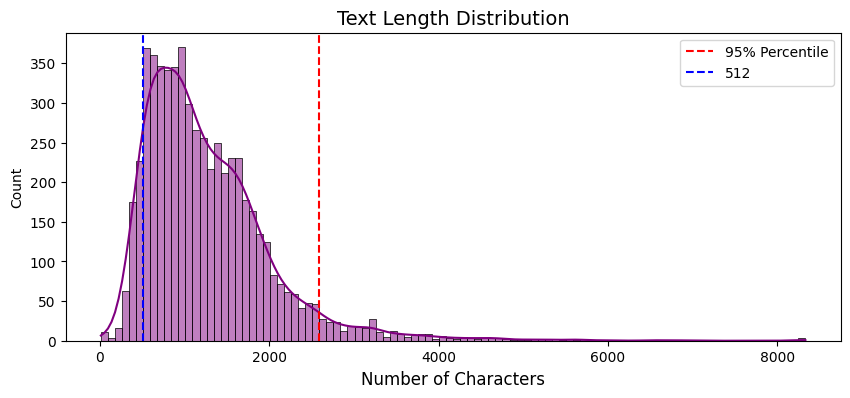

In [112]:
df_train["text_length"] = df_train["content"].apply(len)

plt.figure(figsize=(10, 4))
sns.histplot(df_train["text_length"], bins=100, kde=True, color="purple")
plt.title("Text Length Distribution", fontsize=14)
plt.xlabel("Number of Characters", fontsize=12)
plt.axvline(df_train["text_length"].quantile(0.95), color='red', linestyle='--', label='95% Percentile')
plt.axvline(512, color='blue', linestyle='--', label='512')
plt.legend()
plt.show()

カテゴリ確認

In [78]:
num= dataset["train"].features["category"].num_classes
num

9

In [15]:
train_dataset = dataset["train"]
val_dataset = dataset["validation"]

In [16]:
def preprocess_function(examples):
    return tokenizer(
        examples["content"], 
        truncation=True, 
        max_length=512
    )

In [32]:
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/5894 [00:00<?, ? examples/s]

Map:   0%|          | 0/737 [00:00<?, ? examples/s]

In [34]:
columns_to_keep = ["input_ids", "attention_mask", "token_type_ids", "category"]
tokenized_train = tokenized_train.select_columns(columns_to_keep)
tokenized_val = tokenized_val.select_columns(columns_to_keep)

In [35]:
# カラム名 'category' を、PyTorchの標準である 'labels' にリネーム
tokenized_train = tokenized_train.rename_column("category", "labels")
tokenized_val = tokenized_val.rename_column("category", "labels")

In [36]:
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

In [45]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    tokenized_train, 
    shuffle=True, 
    batch_size=16, 
    collate_fn=data_collator # ここで指定！
)

val_dataloader = DataLoader(
    tokenized_val, 
    batch_size=16, 
    collate_fn=data_collator
)

# テスト出力（バッチの次元を確認）
for batch in train_dataloader:
    print({k: v.shape for k, v in batch.items()})
    break

{'input_ids': torch.Size([16, 512]), 'attention_mask': torch.Size([16, 512]), 'token_type_ids': torch.Size([16, 512]), 'labels': torch.Size([16])}


訓練の際に、BERTの本体の更新をする（そうしないと精度がかなり悪い）

In [ ]:
import torch
from torch.optim import AdamW
from tqdm import tqdm 

In [110]:
num_classes = dataset["train"].features["category"].num_classes

# 9クラス分類のモデルとして新しく初期化
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=num_classes
)

# GPUへ転送
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-v3 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32768, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
#for param in model.bert.parameters():
   # param.requires_grad = False

ここから訓練

In [108]:
from transformers import get_linear_schedule_with_warmup

In [99]:
total_train_steps

1107

In [111]:
optimizer = AdamW(model.parameters(), lr=2e-5)
total_train_steps = len(train_dataloader) * epochs
# ウォームアップステップ数（全体の10%など）
num_warmup_steps = int(total_train_steps * 0.1)

# スケジューラの作成
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_train_steps
)
epochs =8
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("-" * 30)
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_dataloader, desc="Training")
    
    for batch in train_bar:
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # 勾配の初期化
        optimizer.zero_grad()
        
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")
        
    avg_train_loss = train_loss / len(train_dataloader)
    print(f"Average Train Loss: {avg_train_loss:.4f}")
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    val_bar = tqdm(val_dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch in val_bar:
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            # 正解数をカウント（テンソル同士を比較してTrueの数を合計）
            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)
            
    avg_val_loss = val_loss / len(val_dataloader)
    accuracy = correct / total * 100
    
    print(f"Average Val Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")


Epoch 1/8
------------------------------


Training: 100%|██████████| 369/369 [01:34<00:00,  3.90it/s, loss=0.0729]


Average Train Loss: 0.6970


Validation: 100%|██████████| 47/47 [00:04<00:00, 11.24it/s]


Average Val Loss: 1.2038
Validation Accuracy: 66.62%

Epoch 2/8
------------------------------


...

Average Val Loss: 0.9287
Validation Accuracy: 75.85%

Epoch 8/8
------------------------------


Training: 100%|██████████| 369/369 [01:35<00:00,  3.85it/s, loss=0.0171]


Average Train Loss: 0.0470


Validation: 100%|██████████| 47/47 [00:04<00:00, 10.84it/s]

Average Val Loss: 0.9287
Validation Accuracy: 75.85%


精度は、よくて81%くらい。エポック3以降に関して言えば、もう過学習しているのが分かる
実際の、テキストのうち、512トークンしか読み込めないかつ、タイトル等を入れていないので、精度自体は限界である。
今回は実装が目的なので、実装ができたという点で終了する